# Litmus - Persuasion Technique Detector
### Assignment 2: Part A (detection), Part B (span localisation), Part C (product evaluation) by Damiru Wanniarachchi (S4137361)

## How to run
1. Unzip `data_2026_A2.zip` so that this notebook and the extracted data directory are
   siblings (adjust `DATA_ROOT` in Section 1 if your extraction produced a different layout —
   the loader below prints what it finds so this is easy to fix).
2. Place `LABELS.txt` (the 22-technique taxonomy) alongside the data.
3. Run all cells sequentially (Restart & Run All before submitting).


In [1]:
%pip install -q torch transformers numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports & reproducibility
import os, sys, json, glob, random, time, math, re, subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import transformers
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "transformers", "--break-system-packages", "-q"])
    import transformers
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Data exploration



In [3]:
# Load the 22-technique taxonomy
LABELS_PATH = Path("LABELS.txt")
assert LABELS_PATH.exists(), f"Can't find {LABELS_PATH.resolve()} — place LABELS.txt next to this notebook"
with open(LABELS_PATH) as f:
    FULL_TAXONOMY = [line.strip() for line in f if line.strip()]
print(f"Full published taxonomy: {len(FULL_TAXONOMY)} techniques")
FULL_TAXONOMY

Full published taxonomy: 22 techniques


['Appeal to authority',
 'Appeal to fear/prejudice',
 'Black-and-white Fallacy/Dictatorship',
 'Causal Oversimplification',
 'Doubt',
 'Exaggeration/Minimisation',
 'Flag-waving',
 'Glittering generalities (Virtue)',
 'Loaded Language',
 "Misrepresentation of Someone's Position (Straw Man)",
 'Name calling/Labeling',
 'Obfuscation, Intentional vagueness, Confusion',
 'Presenting Irrelevant Data (Red Herring)',
 'Reductio ad hitlerum',
 'Repetition',
 'Slogans',
 'Smears',
 'Thought-terminating cliché',
 'Whataboutism',
 'Bandwagon',
 'Transfer',
 'Appeal to (Strong) Emotions']

In [4]:
# Load the corpus
DATA_ROOT = Path("data_2026_A2")
assert DATA_ROOT.exists(), f"Can't find {DATA_ROOT.resolve()}"

print("Top-level contents of DATA_ROOT:")
for p in sorted(DATA_ROOT.glob("*")):
    print(" ", p.name)

def load_split(split_prefix: str):
    """
    Loads both task1 and task2 files for a given split prefix ('training', 'dev', 'test').
    Merges task 1 document labels and task 2 character spans by sample id.
    """
    task1_path = DATA_ROOT / f"{split_prefix}_set_task1.txt"
    task2_path = DATA_ROOT / f"{split_prefix}_set_task2.txt"

    records = {}

    # 1. Parse Task 1 (Document-level classification)
    if task1_path.exists():
        with open(task1_path, "r", encoding="utf-8") as f:
            t1_data = json.load(f)
        for item in t1_data:
            rid = str(item["id"])
            records[rid] = {
                "id": rid,
                "text": item.get("text", "").strip(),
                "labels": sorted(list(set(item.get("labels", [])))),
                "spans": []
            }

    # 2. Parse Task 2 (Token/Span offsets)
    if task2_path.exists():
        with open(task2_path, "r", encoding="utf-8") as f:
            t2_data = json.load(f)
        for item in t2_data:
            rid = str(item["id"])
            if rid not in records:
                records[rid] = {
                    "id": rid,
                    "text": item.get("text", "").strip(),
                    "labels": [],
                    "spans": []
                }
            
            raw_spans = item.get("labels", [])
            spans = []
            span_labels = set()
            for sp in raw_spans:
                if isinstance(sp, dict):
                    tech = sp.get("technique") or sp.get("label")
                    spans.append({
                        "technique": tech,
                        "start": sp.get("start"),
                        "end": sp.get("end")
                    })
                    if tech:
                        span_labels.add(tech)
            
            records[rid]["spans"] = spans
            # Unify labels across both tasks if Task 1 missing
            records[rid]["labels"] = sorted(list(set(records[rid]["labels"]) | span_labels))

    return list(records.values())

train_records = load_split("training")
dev_records   = load_split("dev")
test_records  = load_split("test")

print(f"\nLoaded: train={len(train_records)}  dev={len(dev_records)}  test={len(test_records)}")
train_records[0]

Top-level contents of DATA_ROOT:
  .ipynb_checkpoints
  dev_set_task1.txt
  dev_set_task2.txt
  test_set_task1.txt
  test_set_task2.txt
  training_set_task1.txt
  training_set_task2.txt

Loaded: train=688  dev=63  test=200


{'id': '128',
 'text': 'THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE',
 'labels': ['Black-and-white Fallacy/Dictatorship'],
 'spans': [{'technique': 'Black-and-white Fallacy/Dictatorship',
   'start': 0,
   'end': 41}]}

In [6]:
# Reconcile taxonomy vs what the corpus actually contains
observed_labels = sorted(set(l for r in (train_records + dev_records + test_records) for l in r["labels"]))
print(f"Techniques observed in the corpus: {len(observed_labels)}")

TAXONOMY = [t for t in FULL_TAXONOMY if t in observed_labels]
unsupported = [t for t in FULL_TAXONOMY if t not in observed_labels]
extra_in_corpus = [t for t in observed_labels if t not in FULL_TAXONOMY]

print(f"Usable techniques (in both LABELS.txt and the corpus): {len(TAXONOMY)}")
print("Techniques in LABELS.txt with NO training signal in this corpus (declared limitation):")
print(" ", unsupported)
if extra_in_corpus:
    print("WARNING: corpus contains technique names not in LABELS.txt: check spelling/casing:")
    print(" ", extra_in_corpus)

LABEL_TO_IDX = {t: i for i, t in enumerate(TAXONOMY)}
NUM_LABELS = len(TAXONOMY)
assert NUM_LABELS == 20, f"Expected 20 usable techniques per the spec, got {NUM_LABELS} - investigate!! before proceeding."


Techniques observed in the corpus: 20
Usable techniques (in both LABELS.txt and the corpus): 20
Techniques in LABELS.txt with NO training signal in this corpus (declared limitation):
  ['Transfer', 'Appeal to (Strong) Emotions']


### Dataset Coverage Limitation:
The given dataset contains training signal for only 20 out of all the 22 techniques in the full task taxonomy. The two techniques that did not appear inthe corpus:
- Transfer
- Appeal to (Strong) Emotions

Without any training instances for these two categories, the model will not have learned signal to activate them. Therefore, cannot predict them on unseen data by construction. This notable constraint is logger upfront for informing the evaluation downstream.

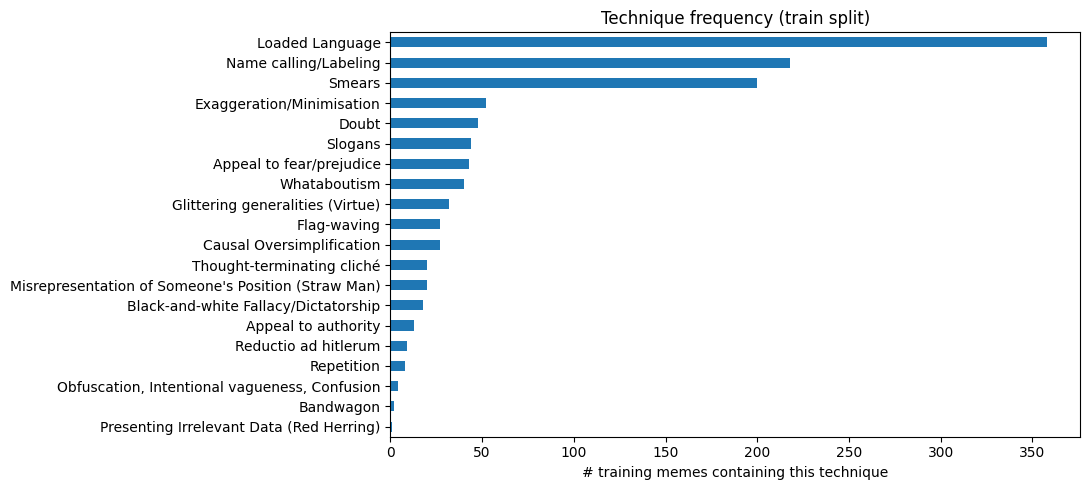

Rarest 5:
 Presenting Irrelevant Data (Red Herring)         1
Bandwagon                                        2
Obfuscation, Intentional vagueness, Confusion    4
Repetition                                       8
Reductio ad hitlerum                             9
dtype: int64

Most common 5:
 Loaded Language              358
Name calling/Labeling        218
Smears                       200
Exaggeration/Minimisation     52
Doubt                         48
dtype: int64

Imbalance ratio (max/min, excluding zero counts): 358.0x

Labels per meme: mean=1.72, median=2.0, max=8, none-of-the-above rate=20.8%


In [7]:
# Class distribution & imbalance
def label_counts(records):
    c = Counter()
    for r in records:
        for l in r["labels"]:
            if l in LABEL_TO_IDX:
                c[l] += 1
    return pd.Series(c).reindex(TAXONOMY).fillna(0).astype(int)

train_counts = label_counts(train_records)
fig, ax = plt.subplots(figsize=(11, 5))
train_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("# training memes containing this technique")
ax.set_title("Technique frequency (train split)")
plt.tight_layout(); plt.show()

print("Rarest 5:\n", train_counts.sort_values().head(5))
print("\nMost common 5:\n", train_counts.sort_values(ascending=False).head(5))
print(f"\nImbalance ratio (max/min, excluding zero counts): "
      f"{train_counts[train_counts>0].max() / train_counts[train_counts>0].min():.1f}x")

n_labels_per_meme = pd.Series([len(r["labels"]) for r in train_records])
print(f"\nLabels per meme: mean={n_labels_per_meme.mean():.2f}, "
      f"median={n_labels_per_meme.median()}, max={n_labels_per_meme.max()}, "
      f"none-of-the-above rate={(n_labels_per_meme==0).mean():.1%}")



> here
write

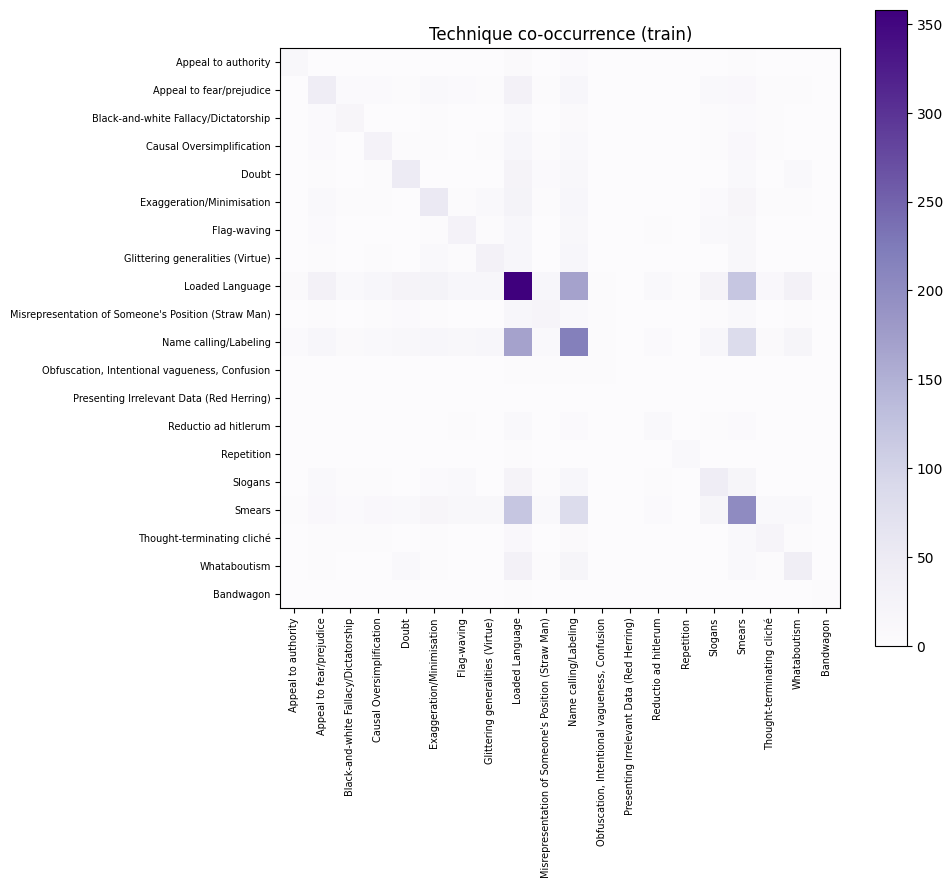

In [8]:
# Label co-occurrence (multi-label -> techniques co-fire)
cooc = pd.DataFrame(0, index=TAXONOMY, columns=TAXONOMY)
for r in train_records:
    labs = [l for l in r["labels"] if l in LABEL_TO_IDX]
    for a in labs:
        for b in labs:
            cooc.loc[a, b] += 1

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cooc.values, cmap="Purples")
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(TAXONOMY, rotation=90, fontsize=7)
ax.set_yticks(range(NUM_LABELS)); ax.set_yticklabels(TAXONOMY, fontsize=7)
ax.set_title("Technique co-occurrence (train)")
plt.colorbar(im); plt.tight_layout(); plt.show()

**What to look for:** any pair of techniques that co-occur almost every time they
individually occur is a hint the model may struggle to tell them apart (they'll be
confusable in Part 9's error analysis, and matters for how we read C3's label/span
disagreement — a shared span between two co-firing techniques is a different situation from
two genuinely independent techniques both firing).

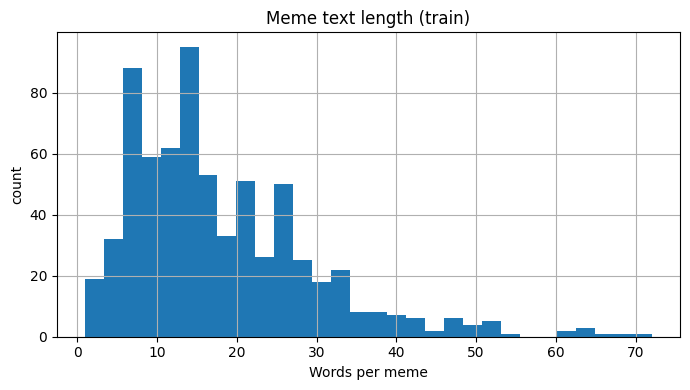

Median words: 15.0, 95th pct: 39, max: 72
Chosen MAX_SEQ_LEN = 69 (short memes -> short sequences -> cheap inference)


In [12]:
# Text length distribution (meme text is short)
lengths = pd.Series([len(r["text"].split()) for r in train_records])
fig, ax = plt.subplots(figsize=(7, 4))
lengths.hist(bins=30, ax=ax)
ax.set_xlabel("Words per meme"); ax.set_ylabel("count")
ax.set_title("Meme text length (train)")
plt.tight_layout(); plt.show()
print(f"Median words: {lengths.median()}, 95th pct: {lengths.quantile(0.95):.0f}, max: {lengths.max()}")
MAX_SEQ_LEN = int(min(128, lengths.quantile(0.99) + 8))  # generous headroom, capped for latency
print(f"Chosen MAX_SEQ_LEN = {MAX_SEQ_LEN} (short memes -> short sequences -> cheap inference)")

In [13]:
# Source-level split integrity check
# If the corpus exposes a page/source id per meme, check whether the SAME source appears in
# both train and test — this is the text-domain analogue of A1's actor-disjoint check, and
# for exactly the same reason: a model can memorise a page's recurring phrasing/meme-template
# rather than learning the technique, inflating test performance.
def get_source_ids(records):
    return set(r.get("source_id", r.get("page_id"))
               for r in records if r.get("source_id") or r.get("page_id"))

train_sources = get_source_ids(train_records)
test_sources  = get_source_ids(test_records)
if train_sources or test_sources:
    overlap = train_sources & test_sources
    print(f"Source ids found. Train sources: {len(train_sources)}, Test sources: {len(test_sources)}, "
          f"overlap: {len(overlap)}")
    if overlap:
        print("WARNING: same source appears in train and test — treat test performance with "
              "extra caution; consider re-splitting by source if this is severe.")
else:
    print("No page/source identifiers available in this corpus release — we cannot directly "
          "verify source-disjointness. Flagged as a limitation on how far the reported test "
          "score generalises (see Ultimate Judgement, Section 9, and Part C4).")

No page/source identifiers available in this corpus release — we cannot directly verify source-disjointness. Flagged as a limitation on how far the reported test score generalises (see Ultimate Judgement, Section 9, and Part C4).
